# Convolutional Variational Autoencoder for Representation Learning

## Overview
This project presents the design, implementation, and training of a **Convolutional Variational Autoencoder (ConvVAE)** for learning compact latent representations from high-dimensional image data. The goal of this project is to study how deep generative models can capture meaningful structure in complex visual inputs through probabilistic latent variable modeling.

The ConvVAE framework combines convolutional encoders and decoders with variational inference, enabling both efficient representation learning and image reconstruction. To improve expressiveness and stability, the model incorporates residual blocks in the decoder and a carefully designed latent space.

## Methodology
The workflow of this notebook includes:
- Loading and preprocessing image data from NPZ files
- Defining a custom PyTorch dataset and data loader
- Implementing a convolutional encoder that maps inputs to latent mean and variance
- Applying the reparameterization trick for stochastic latent sampling
- Reconstructing inputs using a convolutional decoder
- Training the model using reconstruction loss and KL divergence
- Evaluating reconstruction quality and training behavior

## Motivation
Learning low-dimensional representations from high-dimensional data is a fundamental problem in computer vision, multimedia processing, and extended reality (XR) systems. Variational autoencoders provide a principled probabilistic framework for this purpose and are closely related to tasks such as compression, generative modeling, and downstream prediction.

This notebook serves as an exploratory study of representation learning with deep generative models and demonstrates hands-on experience with model architecture design, training dynamics, and empirical evaluation.


In [ ]:
import os

# Set to local project directory
root = os.path.expanduser("/data/coding")
os.chdir(root)

In [8]:
import torch
import random
import numpy as np

# Set a fixed random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

    """Custom PyTorch Dataset for loading images and labels from an NPZ file."""
class CustomDataset(Dataset):
    def __init__(self, npz_path, transform = None):
        npz_data = np.load(npz_path)
        self.images = npz_data["images"] # (N, 3, 128, 128) in np.uint8
        self.labels = npz_data["labels"] # (N,) in np.int64
        self.transform = transform
        assert self.images.shape[0] == self.labels.shape[0]
        print(f"{npz_path}: images shape {self.images.shape}, "
              f"labels shape {self.labels.shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32) / 255.0  # Normalize pixel values to [0, 1]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

train_dataset = CustomDataset("train.npz")
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

train.npz: images shape (18900, 3, 128, 128), labels shape (18900,)


In [10]:
# sample data batch
images, labels = next(iter(train_loader))
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")

images shape: torch.Size([128, 3, 128, 128])
labels shape: torch.Size([128])


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels, 3, padding=1),
        )
    def forward(self, x):
        return x + self.block(x)
        
class ConvVAE(nn.Module):
    def __init__(self, input_channels=3, latent_channels=32):
        super().__init__()

        # --- Encoder ---
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1),  # [B,64,64,64]
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),             # [B,128,32,32]
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),            # [B,256,16,16]
            nn.LeakyReLU(0.2)
        )

        # Quantization conv
        self.quant_conv = nn.Conv2d(256, latent_channels * 2, kernel_size=1)

        # Decoder
        self.post_quant_conv = nn.Conv2d(latent_channels, 256, kernel_size=1)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),   # [B,128,32,32]
            ResBlock(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),    # [B,64,64,64]
            ResBlock(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, input_channels, kernel_size=4, stride=2, padding=1), # [B,3,128,128]
            nn.Sigmoid()
        )

    def preprocess(self, x):
        return 2 * x - 1  

    def encode(self, x):
        x = self.preprocess(x)
        h = self.encoder(x)
        h = self.quant_conv(h)
        mean, logvar = torch.chunk(h, 2, dim=1)
        if self.training:
            logvar = logvar.clamp(-30.0, 20.0)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mean + eps * std
        else:
            z = mean
        return z, mean, logvar

    def decode(self, z):
        h = self.post_quant_conv(z)
        x_recon = self.decoder(h)
        return x_recon

    def forward(self, x):
        z, mean, logvar = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z, mean, logvar


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split, DataLoader
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as T

# --- Dataset & Split ---
full_dataset = CustomDataset('train.npz')
train_size   = int(0.9 * len(full_dataset))
test_size    = len(full_dataset) - train_size
train_ds, test_ds = random_split(full_dataset, [train_size, test_size])


batch_size   = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=True, num_workers=2)

# --- Classifier as before ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR


class ProbeClassifier(nn.Module):
    def __init__(self, z_dim=32, num_classes=170):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),   # pooling to [B,latent_channels,1,1]
            nn.Flatten(),                  # [B,latent_channels]
            nn.Linear(z_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, z):
        return self.net(z)




# ----- Loss Function -----
def vae_loss(x, x_recon, z, mean, logvar, labels, classifier):
    recon_loss   = F.mse_loss(x_recon, x, reduction='mean')
    logits     = classifier(z)
    class_loss = F.cross_entropy(logits, labels)
    final_loss = torch.log(recon_loss + 1e-8)+ torch.log(class_loss + 1e-8)
    return final_loss, recon_loss, class_loss

# ----- Training -----

def train_vae(model, train_loader, test_loader, optimizer_vae, optimizer_cls,  device,
              num_epochs=100):
    best_loss = float('inf')
    scheduler_vae = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vae, T_max=num_epochs, eta_min=1e-5)
    scheduler_cls = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cls, T_max=num_epochs, eta_min=1e-5)
    for epoch in range(1, num_epochs+1):
        model.train()
        classifier.train()
        total_loss=0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
        for x, labels in pbar:
            x, labels = x.to(device), labels.to(device)
            # ---  VAE forward pass & VAE loss ---
            optimizer_vae.zero_grad()
            optimizer_cls.zero_grad()
            x_recon, z, mean, logvar = model(x)
            loss, recon_loss, cls_loss = vae_loss(x, x_recon, z, mean, logvar, labels, classifier)
            loss.backward()
            optimizer_vae.step()
            optimizer_cls.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item(), recon=recon_loss.item(), cls=cls_loss.item())

        scheduler_vae.step() 
        scheduler_cls.step()
        
        # --- evaluate on test set & early stop on recon ---
        model.eval()
        classifier.eval()
        total_test_loss = 0.0
        total_test_recon = 0.0
        tbar = tqdm(test_loader, desc=f"Epoch {epoch}/{num_epochs}")
        with torch.no_grad():
            for x, labels in tbar:
                x, labels = x.to(device), labels.to(device)
                x_recon, z, mean, logvar = model(x)
                test_loss, recon_l, cls_l = vae_loss(x, x_recon, z, mean, logvar, labels, classifier)
                total_test_loss  += test_loss.item()
                total_test_recon += recon_l.item()

        avg_test_loss  = total_test_loss  / len(test_loader)
        avg_test_recon = total_test_recon / len(test_loader)
        print(f"[Test] Avg loss: {avg_test_loss:.4f}, Avg recon: {avg_test_recon:.6f}")

        # save best
        if avg_test_recon < best_loss:
            best_loss = avg_test_recon
            torch.save(model.state_dict(), "best_model.pt")
            print("✅ Saved new best model!")



# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model & Optimizer
model     = ConvVAE().to(device)
classifier  = ProbeClassifier().to(device)
optimizer_vae = optim.Adam(model.parameters(), lr=1e-3)
optimizer_cls = optim.Adam(classifier.parameters(), lr=1e-3)

# Train
train_vae(model, train_loader, test_loader, optimizer_vae, optimizer_cls, device,
          num_epochs=100)


train.npz: images shape (18900, 3, 128, 128), labels shape (18900,)


Epoch 1/100: 100%|██████████| 15/15 [00:02<00:00,  6.59it/s]


[Test] Avg loss: -3.3161, Avg recon: 0.007319
✅ Saved new best model!


Epoch 2/100: 100%|██████████| 15/15 [00:02<00:00,  7.12it/s]


[Test] Avg loss: -3.7292, Avg recon: 0.004915
✅ Saved new best model!


...

[Test] Avg loss: -6.0522, Avg recon: 0.000510


Epoch 99/100: 100%|██████████| 15/15 [00:02<00:00,  6.60it/s]


[Test] Avg loss: -6.0537, Avg recon: 0.000509


Epoch 100/100: 100%|██████████| 15/15 [00:01<00:00, 10.01it/s]

[Test] Avg loss: -6.0543, Avg recon: 0.000510


Latent bottleneck dimension: 8192


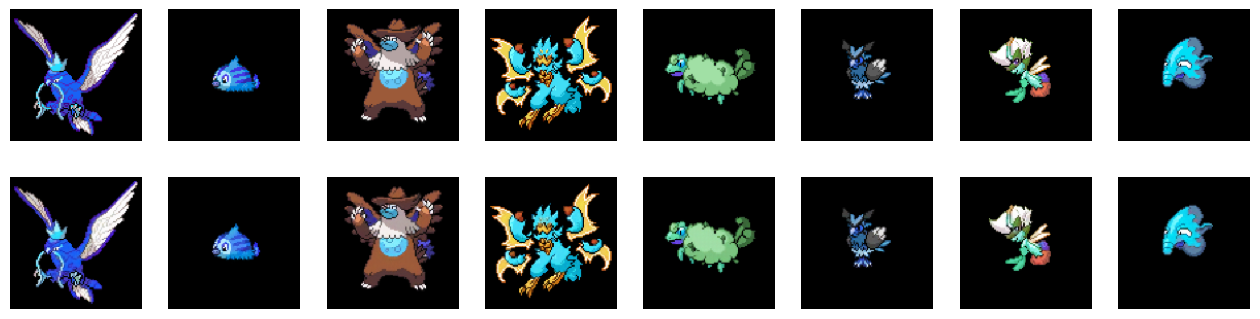

In [13]:
# ----- Visualization -----
def plot_reconstructions(model, dataloader, device, num_images=8):
    model.eval()
    with torch.no_grad():
        x = next(iter(dataloader))[0].to(device)
        x_recon, z, _, _ = model(x)
        x = x.cpu().numpy()
        x_recon = x_recon.cpu().numpy()
        print(f"Latent bottleneck dimension: {z.flatten(start_dim=1).shape[1]}")

        plt.figure(figsize=(16, 4))
        for i in range(num_images):
            # Original
            plt.subplot(2, num_images, i+1)
            plt.imshow(x[i].transpose(1, 2, 0))  # (C, H, W) -> (H, W, C)
            plt.axis('off')

            # Reconstruction
            plt.subplot(2, num_images, i+1+num_images)
            plt.imshow(x_recon[i].transpose(1, 2, 0))
            plt.axis('off')

        plt.show()

plot_reconstructions(model, train_loader, device, num_images=8)